In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person629_bacteria_2509.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person952_bacteria_2877.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1315_virus_2270.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1392_bacteria_3538.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person475_bacteria_2025.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1288_bacteria_3251.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1005_virus_1688.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person442_virus_900.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person755_bacteria_2659.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person655_bacteria_2547.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray

In [ ]:
# Paths
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir   = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir  = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

In [ ]:
# Defining paths for each class within each set.
# Training paths
import os
train_normal_dir = os.path.join(train_dir, 'NORMAL')
train_pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')

# Validation paths
val_normal_dir = os.path.join(val_dir, 'NORMAL')
val_pneumonia_dir = os.path.join(val_dir, 'PNEUMONIA')

# Test paths
test_normal_dir = os.path.join(test_dir, 'NORMAL')
test_pneumonia_dir = os.path.join(test_dir, 'PNEUMONIA')

In [ ]:
# number of images in each category.
num_train_normal = len(os.listdir(train_normal_dir))
num_train_pneumonia = len(os.listdir(train_pneumonia_dir))

num_val_normal = len(os.listdir(val_normal_dir))
num_val_pneumonia = len(os.listdir(val_pneumonia_dir))

num_test_normal = len(os.listdir(test_normal_dir))
num_test_pneumonia = len(os.listdir(test_pneumonia_dir))

total_train = num_train_normal + num_train_pneumonia
total_val = num_val_normal + num_val_pneumonia
total_test = num_test_normal + num_test_pneumonia

# Print the counts
print("Image Counts:")
print(f"Total Training Images: {total_train}")
print(f"  - Normal: {num_train_normal}")
print(f"  - Pneumonia: {num_train_pneumonia}")
print("-" * 20)
print(f"Total Validation Images: {total_val}")
print(f"  - Normal: {num_val_normal}")
print(f"  - Pneumonia: {num_val_pneumonia}")
print("-" * 20)
print(f"Total Testing Images: {total_test}")
print(f"  - Normal: {num_test_normal}")
print(f"  - Pneumonia: {num_test_pneumonia}")
print("-" * 20)

Image Counts:
Total Training Images: 5216
  - Normal: 1341
  - Pneumonia: 3875
--------------------
Total Validation Images: 16
  - Normal: 8
  - Pneumonia: 8
--------------------
Total Testing Images: 624
  - Normal: 234
  - Pneumonia: 390
--------------------


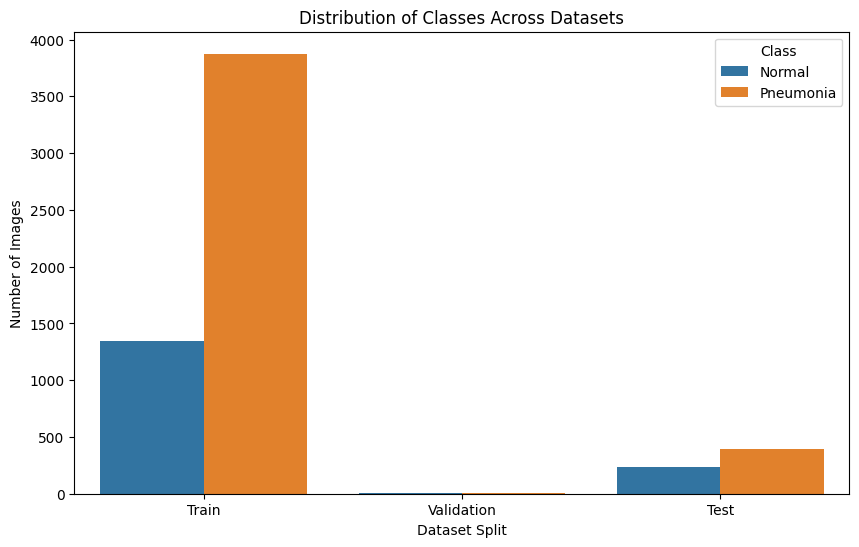

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
data = {
  'Set': ['Train', 'Train', 'Validation', 'Validation', 'Test', 'Test'],
  'Class': ['Normal', 'Pneumonia', 'Normal', 'Pneumonia', 'Normal', 'Pneumonia'],
  'Count': [num_train_normal, num_train_pneumonia, num_val_normal, num_val_pneumonia, num_test_normal, num_test_pneumonia]
}
df_counts = pd.DataFrame(data)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Set', y='Count', hue='Class', data=df_counts)
plt.title('Distribution of Classes Across Datasets')
plt.ylabel('Number of Images')
plt.xlabel('Dataset Split')
plt.show()

Sample 'Normal' Images


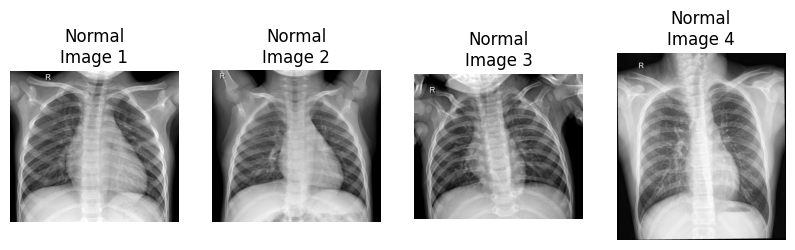


Sample 'Pneumonia' Images


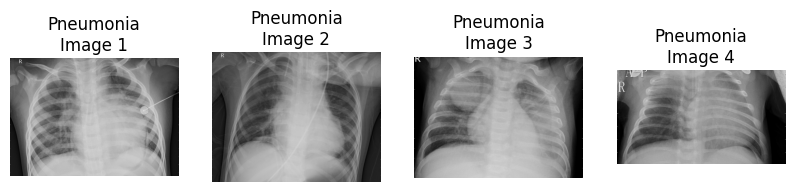

In [ ]:
import cv2
import random

def display_samples(directory, class_name, num_samples=4):
  """Displays a grid of random sample images from a given directory."""
  plt.figure(figsize=(10, 5))
  image_files = os.listdir(directory)
  random_samples = random.sample(image_files, num_samples)

  for i, file in enumerate(random_samples):
    image_path = os.path.join(directory, file)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(image)
    plt.title(f"{class_name}\nImage {i+1}")
    plt.axis('off')
  plt.show()

# Display samples for Normal class from the training set.
print("Sample 'Normal' Images")
display_samples(train_normal_dir, 'Normal')

# Display samples for Pneumonia class from the training set
print("\nSample 'Pneumonia' Images")
display_samples(train_pneumonia_dir, 'Pneumonia')

Significant Class Imbalance: The bar chart and the raw counts clearly show a major imbalance in our training dataset. There are 3,875 images of Pneumonia but only 1,341 Normal images. This means the Pneumonia class is over-represented by a ratio of nearly 3:1.

Validation Set Size: The validation set is extremely small constaining only 16 iamges (8 per class).

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

In [ ]:
# def lr_schedule(epoch, lr):
#     if epoch % 5 == 0 and epoch > 0:
#         lr *= 0.9
#     return float(lr)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,      # reduce LR by 80%
    patience=3,      # wait 3 epochs
    min_lr=1e-7
)


# Create LearningRateScheduler
# Keras callback that applies lr_schedule function every epoch
# learning_rate_scheduler = LearningRateScheduler(lr_schedule)

# Callbacks
# early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_resnet_model.h5",
    monitor="val_loss",
    save_best_only=True
)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
val_data = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
test_data = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from sklearn.utils import class_weight
import numpy as np

labels = train_data.classes

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False   # Stage 1


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


In [ ]:
model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    class_weight=class_weights,
    callbacks=[early_stopping, lr_reducer, checkpoint]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.7159 - loss: 0.5389

163/163 ━━━━━━━━━━━━━━━━━━━━ 171s 951ms/step - accuracy: 0.7164 - loss: 0.5379 - val_accuracy: 0.9375 - val_loss: 0.3120 - learning_rate: 1.0000e-04
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.8991 - loss: 0.2501

163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 663ms/step - accuracy: 0.8991 - loss: 0.2500 - val_accuracy: 0.9375 - val_loss: 0.1991 - learning_rate: 1.0000e-04
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.9229 - loss: 0.1901

163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 657ms/step - accuracy: 0.9229 - loss: 0.1900 - val_accuracy: 0.9375 - val_loss: 0.1480 - learning_rate: 1.0000e-04
Epoch 4/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9298 - loss: 0.1639

163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 656ms/step - accuracy: 0.9298 - loss: 0.1640 - val_accuracy: 0.9375 - val_loss: 0.1356 - learning_rate: 1.0000e-04
Epoch 5/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 647ms/step - accuracy: 0.9439 - loss: 0.1431 - val_accuracy: 0.9375 - val_loss: 0.1392 - learning_rate: 1.0000e-04
Epoch 6/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.9472 - loss: 0.1481

163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 645ms/step - accuracy: 0.9473 - loss: 0.1480 - val_accuracy: 0.9375 - val_loss: 0.0976 - learning_rate: 1.0000e-04
Epoch 7/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9414 - loss: 0.1461

163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 656ms/step - accuracy: 0.9414 - loss: 0.1460 - val_accuracy: 0.9375 - val_loss: 0.0858 - learning_rate: 1.0000e-04
Epoch 8/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.9539 - loss: 0.1204

163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 640ms/step - accuracy: 0.9539 - loss: 0.1204 - val_accuracy: 1.0000 - val_loss: 0.0641 - learning_rate: 1.0000e-04


In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping, lr_reducer, checkpoint]
)


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 696ms/step - accuracy: 0.9410 - loss: 0.1523 - val_accuracy: 0.9375 - val_loss: 0.1243 - learning_rate: 1.0000e-05
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 645ms/step - accuracy: 0.9573 - loss: 0.1129 - val_accuracy: 1.0000 - val_loss: 0.1179 - learning_rate: 1.0000e-05
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 708ms/step - accuracy: 0.9510 - loss: 0.1184 - val_accuracy: 1.0000 - val_loss: 0.1128 - learning_rate: 1.0000e-05
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 641ms/step - accuracy: 0.9598 - loss: 0.0987 - val_accuracy: 1.0000 - val_loss: 0.0955 - learning_rate: 1.0000e-05
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9661 - loss: 0.0909

163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 665ms/step - accuracy: 0.9661 - loss: 0.0909 - val_accuracy: 1.0000 - val_loss: 0.0564 - learning_rate: 1.0000e-05
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 652ms/step - accuracy: 0.9667 - loss: 0.0807 - val_accuracy: 1.0000 - val_loss: 0.0594 - learning_rate: 1.0000e-05
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 659ms/step - accuracy: 0.9717 - loss: 0.0769 - val_accuracy: 1.0000 - val_loss: 0.0659 - learning_rate: 1.0000e-05
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 642ms/step - accuracy: 0.9694 - loss: 0.0645 - val_accuracy: 1.0000 - val_loss: 0.0638 - learning_rate: 1.0000e-05
Epoch 9/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 653ms/step - accuracy: 0.9703 - loss: 0.0693 - val_accuracy: 1.0000 - val_loss: 0.0645 - learning_rate: 2.0000e-06
Epoch 10/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 648ms/step - accuracy: 0.9747 - loss: 0.0619 - val_accuracy: 1.0000 - val_loss: 0.0654 - learning_rate: 2.0000e-06
Epoch 11/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 641m

In [ ]:
# Evaluate on validation set
results = model.evaluate(val_data)
print(f"Validation Loss: {results[0]:.4f}, Validation Accuracy: {results[1]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 1.0000 - loss: 0.0564
Validation Loss: 0.0564, Validation Accuracy: 1.0000


In [ ]:
# Evaluate on test set
test_results = model.evaluate(test_data)
print(f"Test Loss: {test_results[0]:.4f}, Test Accuracy: {test_results[1]:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - accuracy: 0.9220 - loss: 0.2258
Test Loss: 0.2251, Test Accuracy: 0.9247


20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 577ms/step


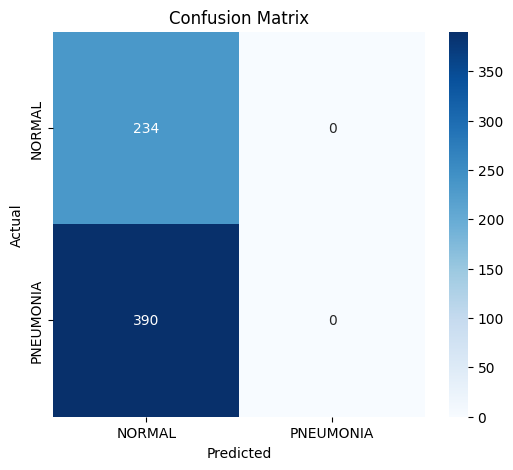

              precision    recall  f1-score   support

           0       0.38      1.00      0.55       234
           1       0.00      0.00      0.00       390

    accuracy                           0.38       624
   macro avg       0.19      0.50      0.27       624
weighted avg       0.14      0.38      0.20       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels from test_data
y_true = test_data.classes

# Predict on test data
y_pred_probs = model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Optional: Classification Report
print(classification_report(y_true, y_pred))


In [ ]:
'''model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,177,157 (206.67 MB)

 Trainable params: 15,011,841 (57.27 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

 Optimizer params: 30,023,684 (114.53 MB)

In [ ]:
'''resnet = model.layers[0]   # THIS is the true ResNet50
for layer in resnet.layers:
    if "conv" in layer.name and "out" in layer.name:
        print(layer.name, layer.output.shape)


conv2_block1_out (None, 56, 56, 256)
conv2_block2_out (None, 56, 56, 256)
conv2_block3_out (None, 56, 56, 256)
conv3_block1_out (None, 28, 28, 512)
conv3_block2_out (None, 28, 28, 512)
conv3_block3_out (None, 28, 28, 512)
conv3_block4_out (None, 28, 28, 512)
conv4_block1_out (None, 14, 14, 1024)
conv4_block2_out (None, 14, 14, 1024)
conv4_block3_out (None, 14, 14, 1024)
conv4_block4_out (None, 14, 14, 1024)
conv4_block5_out (None, 14, 14, 1024)
conv4_block6_out (None, 14, 14, 1024)
conv5_block1_out (None, 7, 7, 2048)
conv5_block2_out (None, 7, 7, 2048)
conv5_block3_out (None, 7, 7, 2048)


In [ ]:
'''resnet = model.layers[0]
print(resnet.get_layer("conv5_block3_out"))


<Activation name=conv5_block3_out, built=True>


In [ ]:
import os
import random

def get_example_paths(root_dir, valid_ext=(".jpg",".jpeg",".png",".bmp",".tif",".tiff")):
    """
    root_dir: main dataset folder containing class subfolders
    returns: dict {class_name: image_path}
    """
    class_to_path = {}

    # list class folders
    for cls in sorted(os.listdir(root_dir)):
        cls_folder = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_folder):
            continue

        # collect all image files in this class
        files = [f for f in os.listdir(cls_folder)
                 if f.lower().endswith(valid_ext)]

        if len(files) == 0:
            continue

        # pick 1 random sample
        sample = random.choice(files)
        class_to_path[cls] = os.path.join(cls_folder, sample)

    return class_to_path

# Example use:
root_dataset = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"
example_paths = get_example_paths(root_dataset)

print(example_paths)


{'NORMAL': '/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0300-0001.jpeg', 'PNEUMONIA': '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person134_bacteria_644.jpeg'}


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
import numpy as np


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
labels = train_data.classes

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False   # Stage 1: Train only classifier

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8,
    class_weight=class_weights
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 142s 701ms/step - accuracy: 0.6578 - loss: 0.6083 - val_accuracy: 0.8750 - val_loss: 0.4269
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 613ms/step - accuracy: 0.8443 - loss: 0.3262 - val_accuracy: 0.8750 - val_loss: 0.2803
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 630ms/step - accuracy: 0.8890 - loss: 0.2479 - val_accuracy: 0.9375 - val_loss: 0.2031
Epoch 4/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 614ms/step - accuracy: 0.8995 - loss: 0.2307 - val_accuracy: 0.9375 - val_loss: 0.1960
Epoch 5/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 617ms/step - accuracy: 0.9128 - loss: 0.1953 - val_accuracy: 0.9375 - val_loss: 0.1648
Epoch 6/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 613ms/step - accuracy: 0.9236 - loss: 0.1882 - val_accuracy: 0.8750 - val_loss: 0.1868
Epoch 7/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 620ms/step - accuracy: 0.9207 - loss: 0.1922 - val_accuracy: 0.9375 - val_loss: 0.1583
Epoch 8/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 610ms/step - accuracy: 0.9264 - loss: 0.

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 136s 660ms/step - accuracy: 0.8916 - loss: 0.3380 - val_accuracy: 0.8750 - val_loss: 0.1618
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 646ms/step - accuracy: 0.9020 - loss: 0.2507 - val_accuracy: 1.0000 - val_loss: 0.1069
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 623ms/step - accuracy: 0.9139 - loss: 0.2093 - val_accuracy: 1.0000 - val_loss: 0.0836
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 613ms/step - accuracy: 0.9141 - loss: 0.2151 - val_accuracy: 1.0000 - val_loss: 0.0846
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 614ms/step - accuracy: 0.9185 - loss: 0.1916 - val_accuracy: 1.0000 - val_loss: 0.0712
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 618ms/step - accuracy: 0.9215 - loss: 0.1804 - val_accuracy: 1.0000 - val_loss: 0.0693
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 618ms/step - accuracy: 0.9294 - loss: 0.1887 - val_accuracy: 1.0000 - val_loss: 0.0749
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 621ms/step - accuracy: 0.9262 -

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - accuracy: 0.8727 - loss: 0.3176
Test Accuracy: 0.8910256624221802


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,135,016 (31.03 MB)

 Trainable params: 1,859,681 (7.09 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

 Optimizer params: 3,719,364 (14.19 MB)

In [ ]:
# -----------------------------
# Convert your trained Sequential model to Functional model
# -----------------------------

base = model.layers[0]  # EfficientNetB0 backbone
gap  = model.layers[1]  # GlobalAveragePooling2D
bn   = model.layers[2]  # BatchNorm
d1   = model.layers[3]
drop1= model.layers[4]
d2   = model.layers[5]
drop2= model.layers[6]
out  = model.layers[7]

inp = tf.keras.Input(shape=(224,224,3))
x = base(inp, training=False)
x = gap(x)
x = bn(x, training=False)
x = d1(x)
x = drop1(x, training=False)
x = d2(x)
x = drop2(x, training=False)
output = out(x)

model_fn = tf.keras.Model(inputs=inp, outputs=output)
print("Functional Model Ready for XAI!")


Functional Model Ready for XAI!


In [ ]:
eff = model_fn.layers[1]   # this is EfficientNetB0 inside your model

for layer in eff.layers:
    if "conv" in layer.name:
        print(layer.name, layer.output.shape)


stem_conv_pad (None, 225, 225, 3)
stem_conv (None, 112, 112, 32)
block1a_dwconv (None, 112, 112, 32)
block1a_project_conv (None, 112, 112, 16)
block2a_expand_conv (None, 112, 112, 96)
block2a_dwconv_pad (None, 113, 113, 96)
block2a_dwconv (None, 56, 56, 96)
block2a_project_conv (None, 56, 56, 24)
block2b_expand_conv (None, 56, 56, 144)
block2b_dwconv (None, 56, 56, 144)
block2b_project_conv (None, 56, 56, 24)
block3a_expand_conv (None, 56, 56, 144)
block3a_dwconv_pad (None, 59, 59, 144)
block3a_dwconv (None, 28, 28, 144)
block3a_project_conv (None, 28, 28, 40)
block3b_expand_conv (None, 28, 28, 240)
block3b_dwconv (None, 28, 28, 240)
block3b_project_conv (None, 28, 28, 40)
block4a_expand_conv (None, 28, 28, 240)
block4a_dwconv_pad (None, 29, 29, 240)
block4a_dwconv (None, 14, 14, 240)
block4a_project_conv (None, 14, 14, 80)
block4b_expand_conv (None, 14, 14, 480)
block4b_dwconv (None, 14, 14, 480)
block4b_project_conv (None, 14, 14, 80)
block4c_expand_conv (None, 14, 14, 480)
block4c_d

In [ ]:
# ------------------ Extract Backbone and Classifier ------------------
backbone = model_fn.get_layer("efficientnetb0")   # EfficientNetB0
backbone.trainable = False   # no effect on XAI

# Now rebuild a clean functional model for XAI only
inp = backbone.input
x = backbone.output

# Rebuild classifier exactly as in your Sequential model
x = model_fn.layers[2](x)   # GAP
x = model_fn.layers[3](x)   # BatchNorm
x = model_fn.layers[4](x)   # Dense 256
x = model_fn.layers[5](x)   # Dropout
x = model_fn.layers[6](x)   # Dense 128
x = model_fn.layers[7](x)   # Dropout
out = model_fn.layers[8](x) # Dense 1 (sigmoid)

model_clean = tf.keras.Model(inputs=inp, outputs=out)
print("Functional model built:", model_clean.input, model_clean.output)


Functional model built: <KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor> <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_262>


In [ ]:
# ==========================================================
#   FINAL FIXED XAI CODE (Works 100% with EfficientNetB0)
# ==========================================================
import tensorflow as tf
import numpy as np
import cv2
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BACKBONE = model_clean
LAST_CONV = "top_conv"

def load_preprocess(path):
    img = load_img(path, target_size=IMG_SIZE)
    orig = np.array(img).astype("uint8")
    x = preprocess_input(img_to_array(img))
    return orig, np.expand_dims(x, 0)

def overlay(orig, mask):
    mask = np.maximum(mask, 0)
    if mask.max() > 0:
        mask /= mask.max()
    mask = np.uint8(mask * 255)
    mask = cv2.applyColorMap(mask, cv2.COLORMAP_JET)
    orig_bgr = cv2.cvtColor(orig, cv2.COLOR_RGB2BGR)
    out = cv2.addWeighted(orig_bgr, 0.6, mask, 0.4, 0)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)


In [ ]:
CLASS_LABELS = ["Normal", "Pneumonia"]

normal_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0033-0001-0002.jpeg"
pneumonia_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1643_virus_2843.jpeg"

In [ ]:
def scorecam(path, top_k=50):
    orig, x = load_preprocess(path)
    act_model = Model(
        inputs=model_clean.input,
        outputs=[BACKBONE.get_layer(LAST_CONV).output, model_clean.output]
    )

    conv_out, _ = act_model(x)
    conv_out = conv_out[0].numpy()
    h,w,c = conv_out.shape

    idx = np.argsort(conv_out.mean((0,1)))[-top_k:]

    weights = []
    for i in idx:
        fmap = conv_out[...,i]
        if fmap.max()==0:
            weights.append(0); continue
        mask = cv2.resize(fmap/fmap.max(), IMG_SIZE)[...,None]
        masked = x * mask[np.newaxis,...]
        w = model_clean.predict(masked, verbose=0)[0][0]
        weights.append(w)

    scoremap = np.sum(conv_out[...,idx] * np.array(weights)[None,None,:], axis=-1)
    scoremap = cv2.resize(scoremap, IMG_SIZE)
    return overlay(orig, scoremap)


In [ ]:
def gradcam(path, layer_name=LAST_CONV):
    orig, x = load_preprocess(path)

    conv_layer = BACKBONE.get_layer(layer_name)

    grad_model = Model(
        inputs=model_clean.input,
        outputs=[conv_layer.output, model_clean.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)

    # Global Average Pooling on gradients
    weights = tf.reduce_mean(grads, axis=(1, 2))

    # Weighted sum of channels
    cam = tf.reduce_sum(tf.multiply(weights[:, None, None, :], conv_out), axis=-1)[0]

    # Normalize
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam = cv2.resize(cam, IMG_SIZE)

    return overlay_heatmap(orig, cam)


In [ ]:
IMG_SIZE = (224, 224)           # (W,H)
DPI = 400                       # output DPI for saving
OUTFILE = "xai_panel_publication.png"
ALPHA = 0.45                    # overlay alpha
SCORECAM_TOPK = 80              # top channels for Score-CAM (lower -> faster)
PERC_CLIP = 98                  # percentile for heatmap clipping (visual boost)
GAMMA = 0.75                    # gamma boost for visibility (0.4..1.0 typical)
GAUSS_SIGMA = 1.0               # smoothing

# -----------------------------------------------------------------------
# 1) detect model variable (tries common names) and backbone / last conv
# -----------------------------------------------------------------------
_model_candidates = ["model", "model_fn", "model_clean"]
model_obj = None
for n in _model_candidates:
    if n in globals():
        model_obj = globals()[n]
        break
if model_obj is None:
    raise RuntimeError("No model found in globals() as 'model' / 'model_fn' / 'model_clean'.")

print("Using model object:", [k for k in _model_candidates if k in globals()][0], "type:", type(model_obj))

# try to find backbone (EfficientNet or ResNet inside a Sequential/Functional wrapper)
backbone = None
for layer in getattr(model_obj, "layers", []):
    # EfficientNet layer typically named 'efficientnetb0' or 'efficientnetb0' instance, but sometimes it's the Functional itself
    name = getattr(layer, "name", "")
    if "efficientnet" in name or "resnet" in name or "vgg" in name:
        backbone = layer
        break
# fallback: maybe the model IS the backbone
if backbone is None and hasattr(model_obj, "get_layer"):
    # try get_layer safe
    for candidate in ["efficientnetb0","resnet50","vgg16"]:
        try:
            backbone = model_obj.get_layer(candidate)
            break
        except Exception:
            pass
if backbone is None:
    # as last resort assume first layer is the backbone
    if len(model_obj.layers) > 0:
        backbone = model_obj.layers[0]

if backbone is None:
    raise RuntimeError("Could not find backbone layer inside your model. Inspect model.summary()")

print("Detected backbone:", backbone.name)

# find a conv layer to use (prefer last conv-like 'top_conv' or 'conv5_block3_out')
candidate_last = None
for lname in ["top_conv", "conv5_block3_out", "block7a_project_conv", "block6d_project_conv", "block5c_project_conv"]:
    try:
        candidate_last = backbone.get_layer(lname)
        last_conv_name = lname
        break
    except Exception:
        candidate_last = None
if candidate_last is None:
    # fallback: search backbone.layers for last layer with rank-4 output
    last_conv_name = None
    for l in reversed(getattr(backbone, "layers", [])):
        outshape = getattr(l, "output_shape", None)
        if outshape is not None and len(outshape) == 4:
            last_conv_name = l.name
            candidate_last = l
            break
if candidate_last is None:
    raise RuntimeError("Couldn't find a conv feature layer in the backbone. Print backbone.summary() to inspect.")
print("Using conv layer:", last_conv_name)

# names for preprocessors
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preproc

Using model object: model type: <class 'keras.src.models.sequential.Sequential'>
Detected backbone: efficientnetb0
Using conv layer: top_conv


In [ ]:
def load_raw(path):
    """For gradient-based methods: use raw normalized image (0..1) so gradients are meaningful"""
    pil = load_img(path, target_size=IMG_SIZE)
    orig = np.array(pil).astype(np.uint8)
    x = img_to_array(pil).astype("float32") / 255.0
    x = np.expand_dims(x, axis=0)
    return orig, x

def apply_boost(heat, perc=PERC_CLIP, gamma=GAMMA, sigma=GAUSS_SIGMA):
    """Clip top percentile, gamma correct, gaussian smooth, normalize"""
    if np.isnan(heat).any():
        heat = np.nan_to_num(heat)
    # clip by percentile
    lo = np.percentile(heat, 100 - perc)
    hi = np.percentile(heat, perc)
    clipped = np.clip(heat, lo, hi)
    clipped = clipped - clipped.min()
    if clipped.max() > 0:
        clipped = clipped / (clipped.max() + 1e-8)
    # gamma and smoothing
    boosted = np.power(clipped, gamma)
    if sigma > 0:
        boosted = gaussian_filter(boosted, sigma=sigma)
    # final normalize
    if boosted.max() > 0:
        boosted = boosted / (boosted.max() + 1e-8)
    return boosted

def overlay_heatmap(orig_rgb, heat_2d, alpha=ALPHA, colormap=cv2.COLORMAP_JET):
    h_uint8 = np.uint8(255 * np.clip(heat_2d, 0, 1))
    heat_color = cv2.applyColorMap(h_uint8, colormap)  # BGR
    orig_bgr = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2BGR)
    blended = cv2.addWeighted(orig_bgr, 1.0 - alpha, heat_color, alpha, 0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

In [ ]:
def saliency(path):
    orig, x = load_raw(path)   # use raw normalized input
    x_t = tf.convert_to_tensor(x, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_t)
        preds = model_obj(x_t, training=False)
        loss = preds[:, 0]
    grads = tape.gradient(loss, x_t)
    if grads is None:
        return overlay_heatmap(orig, np.zeros(IMG_SIZE))
    grads = grads[0].numpy()
    sal = np.max(np.abs(grads), axis=-1)
    sal = cv2.resize(sal, IMG_SIZE)
    sal = apply_boost(sal, perc=max(90, PERC_CLIP))
    return overlay_heatmap(orig, sal)

In [ ]:
def smoothgrad(path, n=20, noise=0.12):
    orig, x = load_raw(path)
    H, W = IMG_SIZE[1], IMG_SIZE[0]
    accum = np.zeros((H, W), dtype=np.float32)
    for _ in range(n):
        noise_img = x + noise * np.random.normal(size=x.shape)
        noise_img = np.clip(noise_img, 0, 1)
        x_t = tf.convert_to_tensor(noise_img, dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(x_t)
            preds = model_obj(x_t, training=False)
            loss = preds[:, 0]
        g = tape.gradient(loss, x_t)
        if g is None:
            continue
        g = g[0].numpy()
        g = np.max(np.abs(g), axis=-1)
        accum += cv2.resize(g, IMG_SIZE)
    if accum.max() == 0:
        smooth = accum
    else:
        smooth = accum / (np.max(accum) + 1e-8)
    smooth = apply_boost(smooth)
    return overlay_heatmap(orig, smooth)

In [ ]:
def occlusion(path, patch=32):
    img_bgr = cv2.imread(path)
    img_bgr = cv2.resize(img_bgr, IMG_SIZE)
    orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    inp = orig.astype("float32") / 255.0
    base = float(model_obj.predict(np.expand_dims(inp, 0), verbose=0)[0][0])
    H, W = IMG_SIZE[1], IMG_SIZE[0]
    heat = np.zeros((H, W), dtype=np.float32)
    for y in range(0, H, patch):
        for x0 in range(0, W, patch):
            temp = orig.copy()
            temp[y:y+patch, x0:x0+patch, :] = 0
            pred = float(model_obj.predict(np.expand_dims(temp.astype("float32")/255.0, 0), verbose=0)[0][0])
            heat[y:y+patch, x0:x0+patch] = base - pred
    if heat.max() > 0:
        heat = heat / (heat.max() + 1e-8)
    heat = apply_boost(heat, perc=95, gamma=0.8, sigma=1.2)
    return overlay_heatmap(orig, heat)

In [ ]:
!pip install scipy

In [ ]:
from scipy.ndimage import gaussian_filter

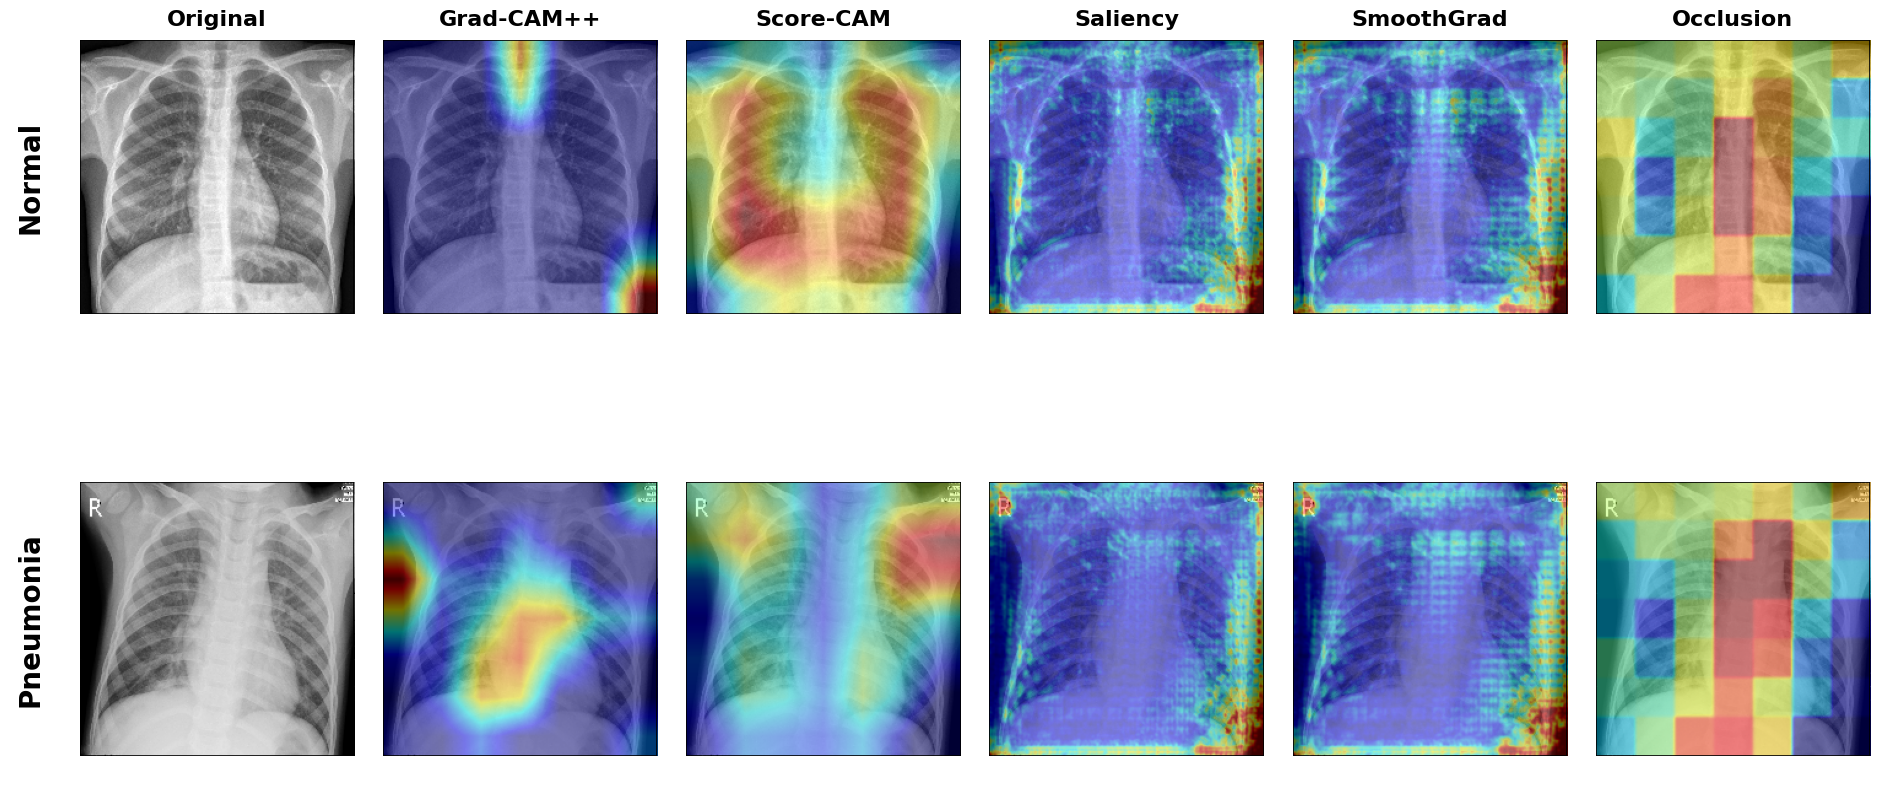

In [ ]:
import matplotlib.patches as patches

paths = [normal_path, pneumonia_path]
methods = [gradcam, scorecam, saliency, smoothgrad, occlusion]
titles = ["Original","Grad-CAM++","Score-CAM","Saliency","SmoothGrad","Occlusion"]
y_labels = ["Normal", "Pneumonia"]

# Load all images
rows=[]
for p in paths:
    orig,_ = load_preprocess(p)
    row=[orig]
    for m in methods:
        row.append(m(p))
    rows.append(row)

# Create figure with clean spacing
fig, ax = plt.subplots(
    2, 7, figsize=(24, 10),
    gridspec_kw={'wspace':0.12, 'hspace':0.35, 'width_ratios':[0.15, 1, 1, 1, 1, 1, 1]}
)

for i in range(2):

    # Row labels (big, centered, bold)
    ax[i,0].text(
        0.5, 0.5, y_labels[i],
        fontsize=20, ha='center', va='center',
        rotation=90, fontweight='bold'
    )
    ax[i,0].axis("off")

    # Images
    for j in range(6):

        ax[i, j+1].imshow(rows[i][j])
        ax[i, j+1].axis("off")

        # Add thin border around each panel
        rect = patches.Rectangle(
            (0,0), 1, 1,
            linewidth=1.2, edgecolor='black',
            facecolor='none',
            transform=ax[i, j+1].transAxes
        )
        ax[i, j+1].add_patch(rect)

        # Titles for top row only
        if i == 0:
            ax[i, j+1].set_title(
                titles[j],
                fontsize=16,
                pad=10,
                fontweight='semibold'
            )

plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 589ms/step
              precision    recall  f1-score   support

      NORMAL       0.91      0.82      0.87       234
   PNEUMONIA       0.90      0.95      0.93       390

    accuracy                           0.90       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.90      0.90      0.90       624



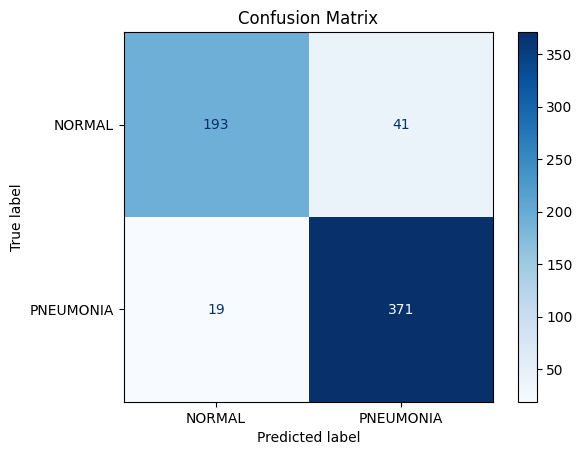

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Get true labels
y_true = test_data.classes

# Get model predictions
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype("int32")  # binary classification

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_data.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

def gradcam_plus_plus(model, img_array, layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape(persistent=True) as tape1:
        with tf.GradientTape(persistent=True) as tape2:
            conv_outputs, predictions = grad_model(img_array)
            pred_index = tf.argmax(predictions[0])
            loss = predictions[:, pred_index]

        first_grad = tape2.gradient(loss, conv_outputs)
    second_grad = tape1.gradient(first_grad, conv_outputs)
    third_grad = tape1.gradient(second_grad, conv_outputs)
    del tape1, tape2

    conv_outputs = conv_outputs[0].numpy()
    first_grad = first_grad[0].numpy()
    second_grad = second_grad[0].numpy()
    third_grad = third_grad[0].numpy()

    global_sum = np.sum(conv_outputs, axis=(0, 1))
    alpha_num = second_grad
    alpha_denom = 2 * second_grad + third_grad * global_sum
    alpha_denom = np.where(alpha_denom != 0, alpha_denom, 1e-10)
    alphas = np.maximum(alpha_num / alpha_denom, 0)

    weights = np.sum(alphas * np.maximum(first_grad, 0), axis=(0, 1))
    cam = np.sum(weights * conv_outputs, axis=-1)

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-10)
    return cam


In [ ]:
def saliency_map(model, img_array):
    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        pred_index = tf.argmax(preds[0])
        loss = preds[:, pred_index]

    grads = tape.gradient(loss, img_tensor)[0].numpy()
    grads = np.max(np.abs(grads), axis=-1)
    grads = (grads - grads.min()) / (grads.max() - grads.min() + 1e-10)
    return grads


In [ ]:
def smoothgrad(model, img_array, n_samples=20, noise=0.15):
    grads_accum = np.zeros((224, 224))

    for _ in range(n_samples):
        noise_img = img_array + noise * np.random.randn(*img_array.shape)
        grads = saliency_map(model, noise_img)
        grads_accum += grads

    grads_accum /= n_samples
    grads_accum = (grads_accum - grads_accum.min()) / (grads_accum.max() - grads_accum.min() + 1e-10)
    return grads_accum


In [ ]:
def occlusion_map(model, img_path, patch=32):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    original = preprocess_input(np.expand_dims(img, axis=0))

    base_pred = model.predict(original)[0]
    pred_index = np.argmax(base_pred)

    heatmap = np.zeros((224, 224))

    for y in range(0, 224, patch):
        for x in range(0, 224, patch):
            temp = img.copy()
            temp[y:y+patch, x:x+patch] = 0

            temp_pp = preprocess_input(np.expand_dims(temp, axis=0))
            pred = model.predict(temp_pp)[0][pred_index]
            heatmap[y:y+patch, x:x+patch] = base_pred[pred_index] - pred

    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-10)
    return heatmap


In [ ]:
def overlay_heatmap(heatmap, original_img, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    return cv2.addWeighted(original_img, 1 - alpha, heatmap, alpha, 0)


In [ ]:
# Load & preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array_raw = cv2.imread(img_path)
img_array_raw = cv2.resize(img_array_raw, (224, 224))

img_array = np.expand_dims(image.img_to_array(img), axis=0)
img_array = preprocess_input(img_array)

# Generate heatmaps
gc_pp = gradcam_plus_plus(model, img_array, layer_name='block5_conv3')
sc    = scorecam(model, img_array, layer_name='block5_conv3')
sal   = saliency_map(model, img_array)
sm    = smoothgrad(model, img_array)
occ   = occlusion_map(model, img_path, patch=32)

# Overlay outputs
outputs = [
    img_array_raw[..., ::-1],  # convert BGR->RGB
    overlay_heatmap(gc_pp, img_array_raw),
    overlay_heatmap(sc, img_array_raw),
    overlay_heatmap(sal, img_array_raw),
    overlay_heatmap(sm, img_array_raw),
    overlay_heatmap(occ, img_array_raw)
]

titles = ["Original", "Grad-CAM++", "Score-CAM", "Saliency", "SmoothGrad", "Occlusion"]
